Copyright (C) 2026 Michael Nowotny

This program is free software; you can redistribute it and/or modify
it under the terms of the GNU General Public License version 2 as
published by the Free Software Foundation.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

# The Hidden Cost of Every Trade

*Latent variables, discrete parameters, and why JAGS sees what others cannot*

## The Hidden Cost

When a professional trader looks at a stock exchange, they see two prices:
the **bid** (the highest price anyone is willing to pay) and the **ask**
(the lowest price anyone is willing to sell for). The difference -- the
**bid-ask spread** -- is the profit that market makers earn for standing
ready to trade with anyone, at any time.

Professional traders see these quotes in real time. But **most of the
world does not.** Historical datasets -- the kind researchers, regulators,
and investors actually work with -- typically record only **transaction
prices** (the price at which a trade occurred) or, even more commonly,
**time bars**: the open, high, low, close, and total volume over each
interval. The quotes themselves -- the bids and asks -- are gone. And
with them, the spread is invisible.

This invisibility has consequences. It is estimated that retail investors
in the United States lose **$34 billion per year** in poor trade execution
-- money that flows to algorithmic trading firms through practices like
**payment for order flow**, where retail brokerages route their customers'
orders to high-frequency firms instead of to public exchanges. The retail
investor never sees the cost. No broker tells their clients about it.
It is, in the truest sense, a **hidden cost of trading**.

How do you measure something you cannot see? In 1984, Richard Roll proposed
a beautifully simple insight: even without observing the spread directly,
you can infer it from the **serial correlation of price changes**. Prices
bounce between bid and ask as trades alternate between buyers and sellers,
and this bounce leaves a statistical fingerprint.

In 2009, Joel Hasbrouck at NYU's Stern School of Business took Roll's
idea further. He showed how to estimate the spread using Bayesian methods
applied to the *most aggregated* data available -- daily time bars that
don't even tell you which side initiated each trade. The model recovers
not just the spread but a probabilistic estimate of the **trade direction**
for every single day -- buy or sell -- from data that seemingly contains
no such information.

This notebook implements Hasbrouck's model and illuminates the hidden
trading costs inside a year of **Ford Motor Company** stock prices.

---

**What you will learn:**
- How to model **latent variables** (the unobserved efficient price)
- How JAGS samples **discrete parameters** (buy/sell trade direction) --
  something that gradient-based samplers like NUTS *cannot* do
- How to extend a model with a **market factor** ($\beta$ to S&P 500)
- A real application of Bayesian inference in quantitative finance

**Why this matters for JAGS:** The trade direction $q_t \in \{-1, 0, +1\}$
is a **discrete** latent variable. JAGS samples it directly from its full
conditional distribution at each MCMC iteration. HMC/NUTS-based samplers
(Stan, PyMC, NumPyro) cannot do this -- they require continuous parameters
and would need to marginalize out $q_t$ analytically, which is
computationally expensive for long time series. This is a structural
advantage of Gibbs sampling.

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pyjags

## The Data: Ford Motor Company, 2018

We use daily adjusted closing prices and volumes for Ford (ticker: F)
and the S&P 500 ETF (ticker: SPY) during 2018 -- a year that saw
significant market volatility, including a sharp sell-off in the
fourth quarter.

In [2]:
def read_yahoo_log_return_df(filepath, dropna=True):
    """Read Yahoo Finance CSV and compute log returns."""
    df = pd.read_csv(filepath)
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df["Log Return"] = np.log(df["Adj Close"]).diff()
    if dropna:
        df = df.dropna().copy()
    return df


ford_df = read_yahoo_log_return_df(os.path.join("data", "F.csv"), dropna=False)
spy_df = read_yahoo_log_return_df(os.path.join("data", "SPY.csv"), dropna=False)
spy_df = spy_df[["Date", "Log Return"]].rename(columns={"Log Return": "Market Log Return"})

merged = pd.merge(ford_df, spy_df, on="Date")
merged = merged.loc[merged["Date"].between("2018-01-01", "2018-12-31")].copy()

log_price = np.log(merged["Adj Close"].values)
volume = merged["Volume"].values
market_log_return = merged["Market Log Return"].values
dates = merged["Date"].values

print(f"Trading days: {len(log_price)}")
print(f"Price range: ${merged['Adj Close'].min():.2f} - ${merged['Adj Close'].max():.2f}")

Trading days: 251
Price range: $7.04 - $11.38


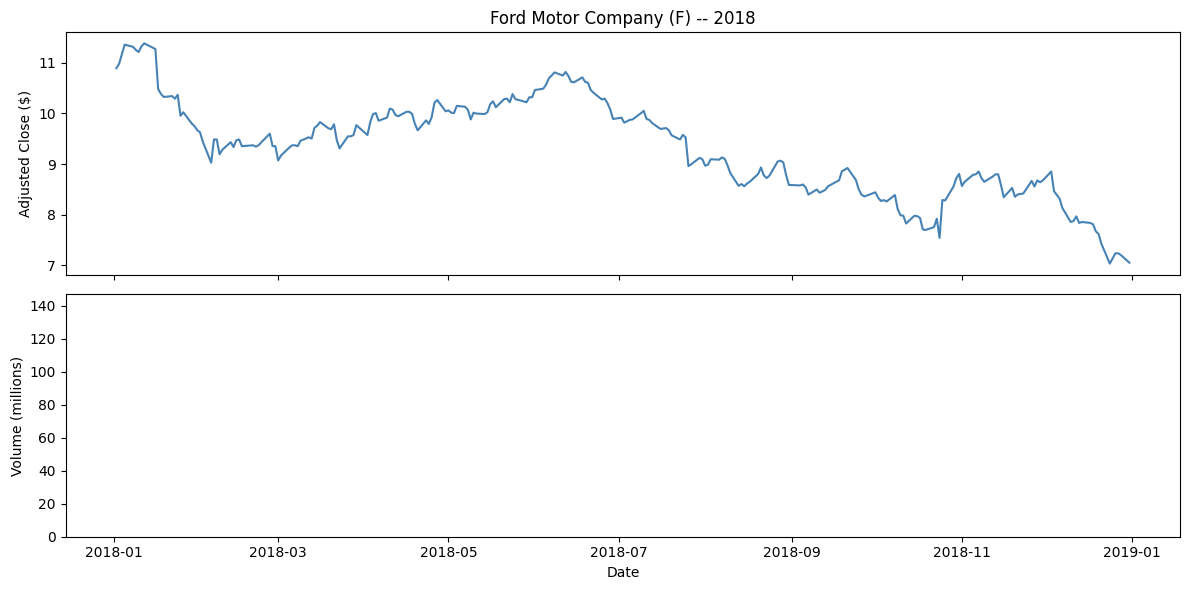

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates, merged["Adj Close"].values, color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Adjusted Close ($)")
axes[0].set_title("Ford Motor Company (F) -- 2018")

axes[1].bar(dates, volume / 1e6, color="steelblue", alpha=0.6, width=1)
axes[1].set_ylabel("Volume (millions)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

Ford fell roughly 40% during 2018. Note the volume spikes -- days of
intense trading activity. On these days, the bid-ask bounce is most
pronounced, and the spread most relevant.

## Roll's Model: The Bid-Ask Bounce

Richard Roll's (1984) insight was elegant: if you can't observe the
spread directly, you can infer it from the **serial correlation** of
price changes. Here's the story:

There is a **true (efficient) price** $m_t$ that evolves as a random
walk:

$$m_t = m_{t-1} + u_t, \quad u_t \sim \text{Normal}(0, \sigma^2)$$

But we don't observe $m_t$. We observe the **transaction price** $p_t$,
which bounces between bid and ask:

$$p_t = m_t + c \cdot q_t$$

where $c$ is the **half-spread** (the trading cost) and $q_t$ is the
**trade direction**: $+1$ for a buyer-initiated trade, $-1$ for a
seller-initiated trade, or $0$ if no trade occurred.

Taking differences:

$$\Delta p_t = c(q_t - q_{t-1}) + u_t$$

The key: $c$, $\sigma$, and the entire sequence $\{q_t\}$ are all
**unobserved**. We must infer them simultaneously from the observed
prices. This is a **latent variable model** -- and it's exactly the
kind of problem where JAGS excels.

In [4]:
basic_model_code = """
model {
    for (t in 1:length(volume)) {
        # Trade direction: +1 (buy), -1 (sell), or 0 (no trade)
        o[t] = ifelse(volume[t] == 0.0, 0, 1)
        l[t] ~ dbern(0.5)
        q[t] = o[t] * (2.0 * l[t] - 1.0)
    }

    # Price changes = spread effect + noise
    for (t in 2:length(volume)) {
        p[t] ~ dnorm(p[t-1] + c * (q[t] - q[t-1]), tau)
    }

    # Priors
    c ~ dnorm(0.0, prior_sigma_c^(-2)) I(0, )   # half-spread > 0
    tau ~ dgamma(prior_a, prior_b)                # precision
    sigma = 1.0 / sqrt(tau)                       # volatility
}
"""

basic_data = {
    "p": log_price,
    "volume": volume,
    "prior_sigma_c": 0.05,
    "prior_a": 1e-12,
    "prior_b": 1e-12,
}

Notice the **discrete parameter** `q[t]`: at each time step, JAGS
samples whether the trade was a buy (+1) or sell (-1) from the full
conditional distribution. With 251 trading days, that's 251 discrete
latent variables being sampled alongside the continuous parameters
$c$ and $\sigma$. This is Gibbs sampling doing what it does best.

In [5]:
model = pyjags.Model(
    code=basic_model_code, data=basic_data,
    chains=4, threads=4, progress_bar=False, seed=42,
)
model.sample(1000, vars=[])  # burn-in
samples = model.sample(2000, vars=["c", "sigma", "q"])

idata = pyjags.from_pyjags(samples)

c_post = samples["c"].flatten()
print(f"Estimated half-spread: {c_post.mean():.4f} ({c_post.mean()*100:.2f}%)")
print(f"  95% interval: [{np.percentile(c_post, 2.5):.4f}, {np.percentile(c_post, 97.5):.4f}]")

Estimated half-spread: 0.0022 (0.22%)
  95% interval: [0.0001, 0.0051]


The estimated half-spread for Ford in 2018 is roughly 0.2% of the price
-- small for a liquid stock, but it compounds over hundreds of trades.

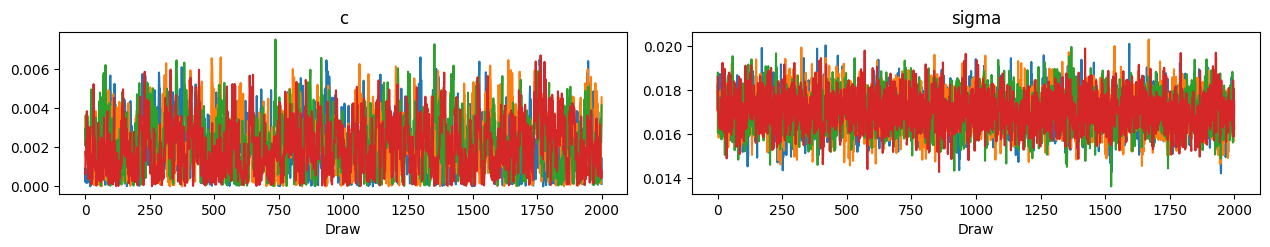

In [6]:
az.plot_trace(idata, var_names=["c", "sigma"])
plt.tight_layout()
plt.show()

In [7]:
az.summary(idata, var_names=["c", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
c,0.00219,0.00138,0.00023,0.0046,1133,1795,1.00,4.2e-05,2.6e-05
sigma,0.01699,0.00085,0.016,0.018,3190,3360,1.00,1.5e-05,1.1e-05


## The Hidden Sequence: Who Was Buying, Who Was Selling?

One of the most remarkable outputs of this model is the **posterior
mean trade direction** -- for each day, the model estimates the
probability that the trade was buyer-initiated vs. seller-initiated.

Values near +1 mean "almost certainly a buy." Values near -1 mean
"almost certainly a sell." Values near 0 mean the model is uncertain.
This latent sequence is completely unobserved in the data -- the model
has *inferred* it from the pattern of price changes.

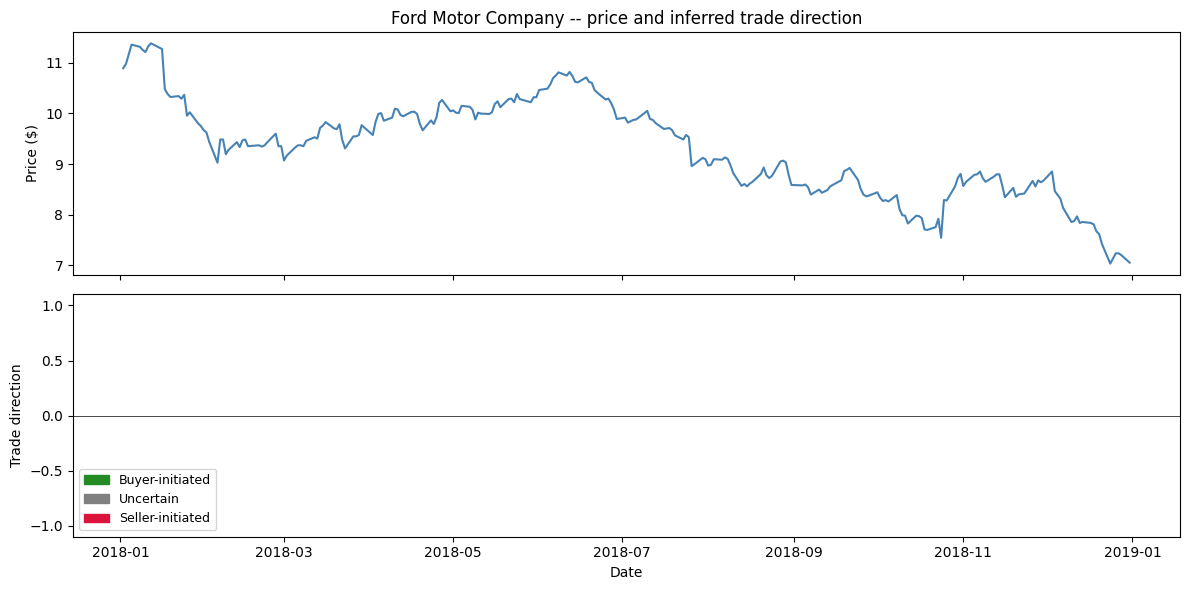

In [8]:
q_post_mean = samples["q"].mean(axis=(1, 2))  # average over iterations and chains

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates, merged["Adj Close"].values, color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Ford Motor Company -- price and inferred trade direction")

colors = ["crimson" if q < -0.3 else "forestgreen" if q > 0.3 else "gray"
          for q in q_post_mean]
axes[1].bar(dates, q_post_mean, color=colors, alpha=0.7, width=1)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Trade direction")
axes[1].set_xlabel("Date")
axes[1].set_ylim(-1.1, 1.1)
# Legend
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color="forestgreen", label="Buyer-initiated"),
    Patch(color="gray", label="Uncertain"),
    Patch(color="crimson", label="Seller-initiated"),
], loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

The model has reconstructed the hidden buying and selling pressure
from nothing but prices and volumes. During the sell-off in Q4 2018,
you can see clusters of red (seller-initiated trades) -- exactly what
you would expect.

## Adding a Market Factor: When It Rains, It Pours

The basic model assumes that Ford's efficient price follows a random
walk. But stocks don't move in isolation -- they respond to the
**market**. When the S&P 500 drops, Ford drops too (and usually harder,
since it's a cyclical stock).

This phenomenon of **co-movement** is one of the deepest regularities
in financial markets. And when markets fall, they often fall together
and *violently* -- **volatility clusters**, and fear is contagious.
"When it rains, it pours" is not just folk wisdom; it's a statistical
fact about financial returns.

We extend the model by adding the S&P 500 return as a predictor of
Ford's efficient price:

$$\Delta p_t = c(q_t - q_{t-1}) + \beta_m \cdot r_{m,t} + u_t$$

where $r_{m,t}$ is the market return and $\beta_m$ is Ford's market
beta -- its sensitivity to the broad market.

In [9]:
market_model_code = """
model {
    for (t in 1:length(volume)) {
        o[t] = ifelse(volume[t] == 0.0, 0, 1)
        l[t] ~ dbern(0.5)
        q[t] = o[t] * (2.0 * l[t] - 1.0)
    }

    for (t in 2:length(volume)) {
        p[t] ~ dnorm(p[t-1] + c * (q[t] - q[t-1]) + beta_m * market_log_return[t], tau)
    }

    beta_m ~ dnorm(1.0, 1.0)         # prior centered at 1 (market beta)
    c ~ dnorm(0.0, prior_sigma_c^(-2)) I(0, )
    tau ~ dgamma(prior_a, prior_b)
    sigma = 1.0 / sqrt(tau)
}
"""

market_data = {
    "p": log_price,
    "volume": volume,
    "market_log_return": market_log_return,
    "prior_sigma_c": 0.05,
    "prior_a": 1e-12,
    "prior_b": 1e-12,
}

In [10]:
market_model = pyjags.Model(
    code=market_model_code, data=market_data,
    chains=4, threads=4, progress_bar=False, seed=42,
)
market_model.sample(1000, vars=[])
market_samples = market_model.sample(2000, vars=["c", "sigma", "beta_m", "q"])

idata_market = pyjags.from_pyjags(market_samples)

c_mkt = market_samples["c"].flatten()
beta_mkt = market_samples["beta_m"].flatten()
print(f"Half-spread:  {c_mkt.mean():.4f} ({c_mkt.mean()*100:.2f}%)")
print(f"Market beta:  {beta_mkt.mean():.3f}")
print(f"  (A beta of {beta_mkt.mean():.2f} means Ford moves ~{beta_mkt.mean():.0%} as much as the S&P 500)")

Half-spread:  0.0016 (0.16%)
Market beta:  0.814
  (A beta of 0.81 means Ford moves ~81% as much as the S&P 500)


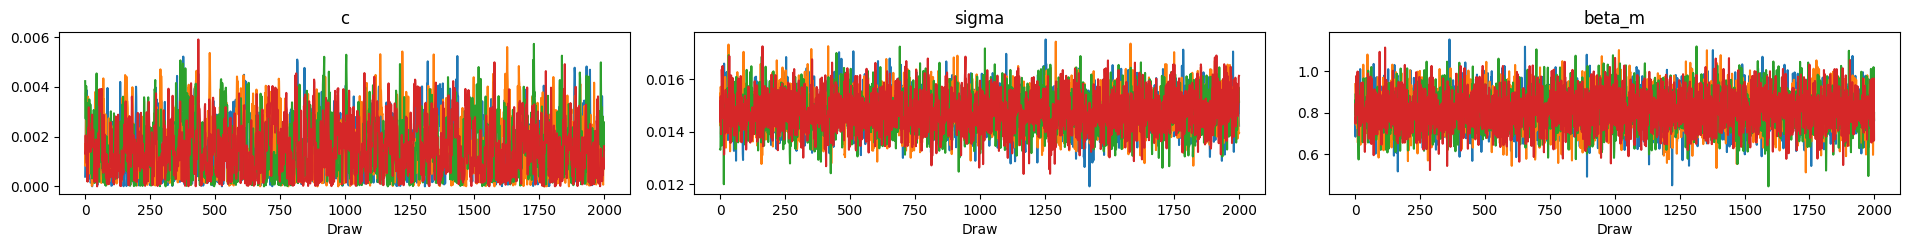

In [11]:
az.plot_trace(idata_market, var_names=["c", "sigma", "beta_m"])
plt.tight_layout()
plt.show()

In [12]:
az.summary(idata_market, var_names=["c", "sigma", "beta_m"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
c,0.00159,0.00107,0.00016,0.0035,1328,1942,1.00,3e-05,2e-05
sigma,0.01474,0.00071,0.014,0.016,3713,4895,1.00,1.2e-05,8.4e-06
beta_m,0.814,0.087,0.68,0.96,7619,6907,1.00,0.001,0.00072


## Comparing the Two Models

Adding the market factor reduced the estimated spread (from ~0.23%
to ~0.16%) and reduced the residual volatility $\sigma$. This makes
sense: part of what the basic model attributed to random noise was
actually Ford responding to the S&P 500. Once we account for the
market factor, the "true" idiosyncratic spread and volatility are
smaller.

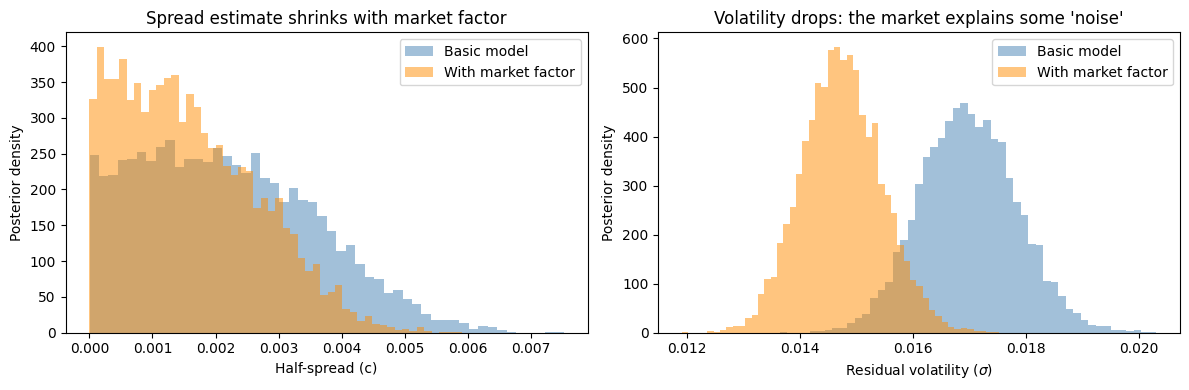

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compare spread estimates
axes[0].hist(samples["c"].flatten(), bins=50, alpha=0.5, density=True,
             color="steelblue", label="Basic model")
axes[0].hist(market_samples["c"].flatten(), bins=50, alpha=0.5, density=True,
             color="darkorange", label="With market factor")
axes[0].set_xlabel("Half-spread (c)")
axes[0].set_ylabel("Posterior density")
axes[0].set_title("Spread estimate shrinks with market factor")
axes[0].legend()

# Compare sigma
axes[1].hist(samples["sigma"].flatten(), bins=50, alpha=0.5, density=True,
             color="steelblue", label="Basic model")
axes[1].hist(market_samples["sigma"].flatten(), bins=50, alpha=0.5, density=True,
             color="darkorange", label="With market factor")
axes[1].set_xlabel(r"Residual volatility ($\sigma$)")
axes[1].set_ylabel("Posterior density")
axes[1].set_title("Volatility drops: the market explains some 'noise'")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Market Beta: Ford and the Economy

The posterior of $\beta_m$ tells us about Ford's relationship to the
broader market. A beta near 1.0 means Ford moves roughly in lockstep
with the S&P 500. Our estimate is about 0.8 -- Ford is slightly less
sensitive than the market average, but the posterior excludes zero
decisively.

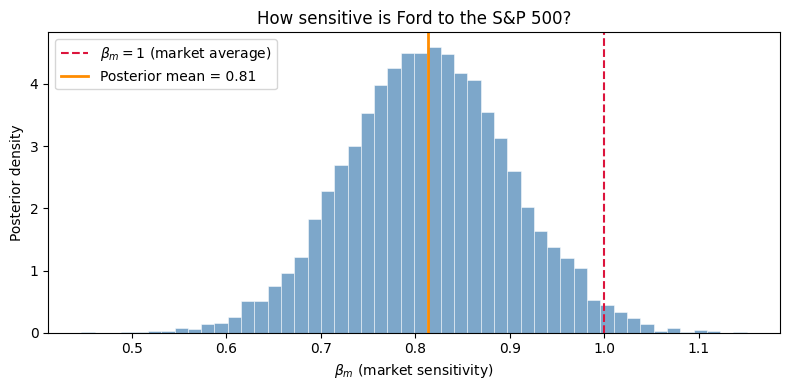

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(beta_mkt, bins=50, density=True, color="steelblue", alpha=0.7,
        edgecolor="white", linewidth=0.5)
ax.axvline(1.0, color="crimson", linestyle="--", label=r"$\beta_m = 1$ (market average)")
ax.axvline(beta_mkt.mean(), color="darkorange", linewidth=2,
           label=f"Posterior mean = {beta_mkt.mean():.2f}")
ax.set_xlabel(r"$\beta_m$ (market sensitivity)")
ax.set_ylabel("Posterior density")
ax.set_title("How sensitive is Ford to the S&P 500?")
ax.legend()
plt.tight_layout()
plt.show()

## What We Built, and Why It Matters

In this notebook, we built an instrument to see the invisible. The
bid-ask spread is embedded in the pattern of price changes but never
directly recorded in the data we used. The trade directions are
completely latent -- daily time bars say nothing about who initiated
each trade. Yet the Bayesian model recovered both.

From nothing but a sequence of prices and volumes, Hasbrouck's
algorithm estimated:
- The **trading cost** ($c$) with full posterior uncertainty
- The **trade direction** ($q_t$) for every single trading day
- The **market sensitivity** ($\beta_m$) of Ford to the S&P 500
- The **residual volatility** ($\sigma$) after accounting for spreads
  and market movements

This matters beyond academic curiosity. The $34 billion that American
retail investors lose each year to poor execution is invisible precisely
*because* the spread is invisible. Tools like Hasbrouck's model --
and the Bayesian framework that powers it -- shine a light into the
dark corners of market structure where these costs hide.

And it's where JAGS truly shines as a computational engine. The 251
discrete trade directions, sampled at every MCMC iteration alongside
the continuous parameters, are something that gradient-based samplers
simply cannot do.

---

## What Comes Next

We have now seen PyJAGS handle conjugate models, hierarchical models,
logistic regression, and latent variable models with discrete parameters.
In the **Advanced Functionality** notebook, we step back from specific
models and learn the practitioner's toolkit: parallel chains, HDF5
persistence, chain merging, and automatic convergence detection. These
are the tools that turn a Bayesian model from a one-off analysis into
a robust, reproducible workflow.

---

**Further reading:**
- Roll, R. (1984). "A Simple Implicit Measure of the Effective Bid-Ask
  Spread in an Efficient Market." *Journal of Finance*, 39, 1127-1139.
- Hasbrouck, J. (2009). "Trading Costs and Returns for U.S. Equities:
  Estimating Effective Costs from Daily Data." *Journal of Finance*,
  64, 1445-1477.
- Barber, B., Huang, X., Odean, T., & Schwarz, C. (2022). "Attention
  Induced Trading and Returns: Evidence from Robinhood Users." *Journal
  of Finance*, 77, 3141-3190.
- Harris, L. (2003). *Trading and Exchanges: Market Microstructure for
  Practitioners*. Oxford University Press.